# Training — GPT-2 Large (774M) on FineWeb-Edu

Continues from `GPTModel.ipynb` (architecture). Model code is imported from `src/gpt_model.py`.

Follows [`TRAINING_PLAN.md`](../TRAINING_PLAN.md), Path A: train from scratch on FineWeb-Edu. Plan C selected — **GPT-2 Large (774M)** on the `sample-100BT` split, ~15B tokens for Chinchilla-optimal convergence.

## Pipeline
1. Imports & device setup
2. Streaming FineWeb-Edu dataloader (BPE tokenize → pack into fixed windows)
3. Train / val split
4. Dataloader smoke test
5. Loss & perplexity helpers
6. Text generation (temperature + top-k)
7. Baseline evaluation (untrained model)
8. AdamW parameter groups (weight decay on matrices only)
9. LR schedule (linear warmup → cosine decay)
10. Checkpoint I/O (with rotation — checkpoints are ~9 GB each)
11. Training loop (bf16 autocast, gradient accumulation, gradient clipping)
12. Long training run (~28K optimizer steps, ~15B tokens, ~8 days on RTX 5090 Laptop)
13. Post-training generation

## Scale
| | |
|---|---|
| Architecture | GPT-2 Large: 36 layers, 1280 emb_dim, 20 heads, 5120 FFN |
| Parameters | ~774M |
| Dataset | FineWeb-Edu `sample-100BT` (~15% epoch) |
| Effective batch | 524 288 tokens (batch 2 × ctx 1024 × accum 256) |
| Optimizer steps | 28 000 |
| Tokens trained | ~14.7B (~19 tok/param — Chinchilla-optimal) |
| Wall clock | ~8 days at ~25 K tokens/sec sustained |

## 1 — Imports & device setup

Pull in the GPT-2 model from `src/gpt_model.py`, tiktoken for BPE, `datasets` for streaming FineWeb-Edu. Pick CUDA + bf16 (RTX 5090 Laptop supports it natively — fastest option, no loss scaler needed).

In [1]:
import os
# Must be set BEFORE importing torch — lets the CUDA allocator reuse fragmented memory.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import sys
import math
import time
import json
from pathlib import Path
from importlib.metadata import version

import torch
import torch.nn as nn
import tiktoken
import matplotlib.pyplot as plt
import wandb

# Make src/ importable
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from gpt_model import GPTModel, GPT_CONFIG_774M as CONFIG

# Device + dtype
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32

# Reproducibility
SEED = 123
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Speed knobs for Ampere+ GPUs (TF32 matmul, cuDNN autotune)
torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

# Paths
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"torch:        {version('torch')}")
print(f"tiktoken:     {version('tiktoken')}")
print(f"datasets:     {version('datasets')}")
print(f"wandb:        {version('wandb')}")
print(f"device:       {device} ({torch.cuda.get_device_name(0) if device.type == 'cuda' else 'cpu'})")
print(f"dtype:        {dtype}")
print(f"seed:         {SEED}")
print(f"ckpt dir:     {CHECKPOINT_DIR}")
print(f"alloc conf:   {os.environ.get('PYTORCH_CUDA_ALLOC_CONF')}")
print(f"\nmodel config (CONFIG):")
for k, v in CONFIG.items():
    print(f"  {k:18s} {v}")

torch:        2.9.0
tiktoken:     0.9.0
datasets:     4.3.0
wandb:        0.23.0
device:       cuda (NVIDIA GeForce RTX 5090 Laptop GPU)
dtype:        torch.bfloat16
seed:         123
ckpt dir:     /home/bmartins/dev/llm_training/checkpoints
alloc conf:   expandable_segments:True

model config (CONFIG):
  vocab_size         50257
  context_length     1024
  emb_dim            1280
  n_heads            20
  n_layers           36
  drop_rate          0.0
  qkv_bias           False


/home/bmartins/anaconda3/envs/llm-scratch/lib/python3.11/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## 2 — Streaming FineWeb-Edu dataloader

Causal LM training needs a stream of `(input, target)` pairs where `target = input shifted by one`. FineWeb-Edu ships as variable-length documents, so we:

1. **Tokenize** each doc with tiktoken GPT-2 BPE.
2. **Concatenate** docs in a rolling buffer, inserting `<|endoftext|>` (id `50256`) between them so the model learns to reset context at document boundaries.
3. **Pack** the buffer into non-overlapping windows of `context_length + 1` tokens. Each window becomes one training sample: `input = window[:-1]`, `target = window[1:]`.

The class takes a pre-configured HuggingFace streaming dataset (already filtered / skipped / shuffled), which makes the train/val split in the next section trivial.

> **Note on workers:** streaming + multi-worker DataLoader needs explicit sharding via `hf_dataset.shard(...)`. We use `num_workers=0` — tokenization is fast enough on a single thread at our batch sizes.

In [2]:
from torch.utils.data import IterableDataset, DataLoader


class PackedTextDataset(IterableDataset):
    """
    Packs a streaming document dataset into fixed-size (input, target) pairs
    for causal LM training.

    Each document is tokenized and appended to an internal buffer, followed by
    an <|endoftext|> separator. Whenever the buffer has >= context_length + 1
    tokens, one non-overlapping window is sliced off and yielded.

    Args:
        hf_dataset:     a HuggingFace IterableDataset of text rows. Apply
                        take/skip/shuffle BEFORE passing it in.
        context_length: tokens per training sample.
        text_field:     column name holding the document text.
        skip_offset:    docs already skipped upstream before this dataset (resume bookkeeping).
                        `docs_consumed` returns skip_offset + docs pulled by this instance,
                        so the cumulative count survives across kernel restarts when saved
                        in the checkpoint and replayed via build_dataloaders(skip_train_docs=...).
    """
    EOT_ID = 50256  # tiktoken GPT-2 <|endoftext|>

    def __init__(self, hf_dataset, context_length: int, text_field: str = "text", skip_offset: int = 0):
        super().__init__()
        self.hf_dataset      = hf_dataset
        self.context_length  = context_length
        self.text_field      = text_field
        self.tokenizer       = tiktoken.get_encoding("gpt2")
        self._skip_offset    = skip_offset
        self._docs_in_iter   = 0

    @property
    def docs_consumed(self) -> int:
        return self._skip_offset + self._docs_in_iter

    def __iter__(self):
        window = self.context_length + 1
        buf: list[int] = []
        for row in self.hf_dataset:
            ids = self.tokenizer.encode_ordinary(row[self.text_field])
            buf.extend(ids)
            buf.append(self.EOT_ID)
            self._docs_in_iter += 1
            while len(buf) >= window:
                chunk = buf[:window]
                buf = buf[window:]
                t = torch.tensor(chunk, dtype=torch.long)
                yield t[:-1], t[1:]


print("PackedTextDataset defined.")
print(f"EOT token: {PackedTextDataset.EOT_ID}  →  {tiktoken.get_encoding('gpt2').decode([PackedTextDataset.EOT_ID])!r}")

PackedTextDataset defined.
EOT token: 50256  →  '<|endoftext|>'


## 3 — Train / val split

FineWeb-Edu only ships a `train` split, so we carve a validation set out of it ourselves:

- **Val:** the first `VAL_DOCS` documents of the stream, no shuffling → a fixed, reproducible set. Val loss across runs is directly comparable.
- **Train:** `skip(VAL_DOCS)` then `.shuffle(buffer_size=...)` → everything after the val set, with a buffered shuffle so consecutive batches aren't sequential docs.

Document-level split prevents any train/val leakage even though our packed windows sometimes mix documents.

### Top-level training config (Plan C — GPT-2 Large)

| Knob | Value | Notes |
|---|---|---|
| `BATCH_SIZE` | 2 | Per forward pass. ~17 GB VRAM at ctx 1024, leaving ~7 GB headroom on 24 GB. |
| `GRAD_ACCUM_STEPS` | 256 | 2 × 256 × 1024 = 524 288 tokens / optimizer step (matches GPT-2 paper). |
| `CONTEXT_LENGTH` | 1024 | From `CONFIG` (`GPT_CONFIG_774M`). |
| `VAL_DOCS` | 500 | ~500 docs ≈ ~50 packed windows (val is sparse but reproducible). |
| `SHUFFLE_BUFFER` | 10 000 | Docs held for shuffling; ~hundreds of MB RAM after tokenization. |
| `DATASET_SUBSET` | `"sample-100BT"` | 100B-token shard; we'll consume ~15% during training. |

If `BATCH_SIZE=2` OOMs on your GPU, drop to `BATCH_SIZE=1` and bump `GRAD_ACCUM_STEPS=512` to keep the same effective batch.

In [3]:
from datasets import load_dataset

# Training config (Plan C — GPT-2 Large)
BATCH_SIZE        = 1
GRAD_ACCUM_STEPS  = 512
CONTEXT_LENGTH    = CONFIG["context_length"]
VAL_DOCS          = 500
SHUFFLE_BUFFER    = 10_000

DATASET_NAME   = "HuggingFaceFW/fineweb-edu"
DATASET_SUBSET = "sample-100BT"


def build_dataloaders(
    batch_size: int = BATCH_SIZE,
    context_length: int = CONTEXT_LENGTH,
    val_docs: int = VAL_DOCS,
    shuffle_buffer: int = SHUFFLE_BUFFER,
    seed: int = SEED,
    skip_train_docs: int = 0,
):
    """
    Return (train_loader, val_loader) streaming from FineWeb-Edu.

    `skip_train_docs` advances the train stream by that many documents before the
    shuffle is applied — used on resume to skip past docs already seen in prior
    runs. Note: the shuffle buffer over a skipped stream is not bit-identical to
    a continuous run with the same seed, but it does avoid retraining on seen
    docs, which is what matters for progress.
    """
    raw = load_dataset(
        DATASET_NAME, name=DATASET_SUBSET, split="train", streaming=True
    )

    val_docs_stream   = raw.take(val_docs)
    train_docs_stream = raw.skip(val_docs + skip_train_docs).shuffle(buffer_size=shuffle_buffer, seed=seed)

    val_ds   = PackedTextDataset(val_docs_stream,   context_length)
    train_ds = PackedTextDataset(train_docs_stream, context_length, skip_offset=skip_train_docs)

    val_loader   = DataLoader(val_ds,   batch_size=batch_size, num_workers=0, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, num_workers=0, pin_memory=True)
    return train_loader, val_loader


train_loader, val_loader = build_dataloaders()

effective_batch_seqs   = BATCH_SIZE * GRAD_ACCUM_STEPS
effective_batch_tokens = effective_batch_seqs * CONTEXT_LENGTH
print(f"micro-batch:     {BATCH_SIZE} seqs  ({BATCH_SIZE * CONTEXT_LENGTH:,} tokens)")
print(f"grad accum:      {GRAD_ACCUM_STEPS}")
print(f"effective batch: {effective_batch_seqs} seqs  ({effective_batch_tokens:,} tokens / optim step)")
print(f"context length:  {CONTEXT_LENGTH}")
print(f"val docs:        {VAL_DOCS}")
print(f"shuffle buffer:  {SHUFFLE_BUFFER:,}")
print(f"dataset subset:  {DATASET_SUBSET}")

/home/bmartins/anaconda3/envs/llm-scratch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


micro-batch:     1 seqs  (1,024 tokens)
grad accum:      512
effective batch: 512 seqs  (524,288 tokens / optim step)
context length:  1024
val docs:        500
shuffle buffer:  10,000
dataset subset:  sample-100BT


## 4 — Dataloader smoke test

Three checks:

1. **Shapes** — `[BATCH_SIZE, CONTEXT_LENGTH]` for both inputs and targets.
2. **Shift invariant** — targets are inputs shifted by one, so `input[:, 1:] == target[:, :-1]` must hold exactly.
3. **Content** — decode the first sample to confirm real FineWeb-Edu text comes out.

The **first** call to `next(iter(loader))` will pull the first shard from the HuggingFace CDN (and cache it to `~/.cache/huggingface/`). Expect ~10–60 s on first run, then fast.

In [4]:
tokenizer = tiktoken.get_encoding("gpt2")

# Pull one batch from each loader
t0 = time.time()
x_train, y_train = next(iter(train_loader))
t_train = time.time() - t0

t0 = time.time()
x_val, y_val = next(iter(val_loader))
t_val = time.time() - t0

print(f"train batch: input {tuple(x_train.shape)}, target {tuple(y_train.shape)}   ({t_train:.1f}s)")
print(f"val batch:   input {tuple(x_val.shape)},   target {tuple(y_val.shape)}   ({t_val:.1f}s)")

# Shift invariant
assert torch.equal(x_train[:, 1:], y_train[:, :-1]), "train: target != input shifted by 1"
assert torch.equal(x_val[:, 1:],   y_val[:, :-1]),   "val:   target != input shifted by 1"
print("Shift invariant OK: target == input rolled left by one.")

# Decode the first sample of the train batch (first 300 tokens)
preview = tokenizer.decode(x_train[0, :300].tolist())
print("\n--- train sample [0], first 300 tokens ---")
print(preview)

train batch: input (1, 1024), target (1, 1024)   (3.2s)
val batch:   input (1, 1024),   target (1, 1024)   (1.4s)
Shift invariant OK: target == input rolled left by one.

--- train sample [0], first 300 tokens ---
Fly ash isn't just filler in concrete. As a very fine-grained pozzolan, it reacts with the calcium hydroxide that is generated by the hydration reaction of cement and water to take on cementitious properties of its own. The reaction makes concrete stronger, less permeable, and reduces the alkalinity, which can reduce the danger of alkali-silica reactivity in the aggregate—and the need in some parts of the country to import nonreactive aggregate from distant sources.
Fly ash concrete is more workable and pumpable. It also hydrates more slowly, which reduces the heat of hydration—critical to reducing cracking in mass concrete placements. All of this makes fly ash concrete more durable than plain portland cement concrete. And concrete with fly ash costs less, because fly ash is 

## 5 — Loss & perplexity

Causal LM loss is just cross-entropy between the model's next-token logits and the target ids, averaged over every position in the batch.

- `calc_loss_batch(x, y, model)` — one forward pass under **bf16 autocast**, returning a scalar loss tensor. Gradients flow through it (used inside the training loop).
- `calc_loss_loader(loader, model, num_batches)` — mean loss over the first `num_batches` batches. Wrapped in `@torch.no_grad()` for evaluation.
- `perplexity(loss) = exp(loss)` — reported alongside loss for intuition.

### Reference values

A randomly-initialized model should predict uniform over the vocab, giving:

$$\text{loss} = \ln(V) = \ln(50257) \approx 10.82, \quad \text{PPL} = V = 50257$$

Trained reference numbers (rough targets):
- GPT-2 Small (124M) ≈ 3.3 loss / 27 PPL
- GPT-2 Medium (350M) ≈ 3.0 loss / 20 PPL
- **GPT-2 Large (774M) ≈ 2.8 loss / 16 PPL** — our convergence target on FineWeb-Edu

In [5]:
def calc_loss_batch(input_batch, target_batch, model):
    """Forward pass + cross-entropy on one (input, target) pair. Gradients enabled."""
    input_batch  = input_batch.to(device, non_blocking=True)
    target_batch = target_batch.to(device, non_blocking=True)
    use_amp = device.type == "cuda"
    with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
        logits = model(input_batch)                         # [B, T, V]
        loss = nn.functional.cross_entropy(
            logits.flatten(0, 1),                           # [B*T, V]
            target_batch.flatten(),                         # [B*T]
        )
    return loss


@torch.no_grad()
def calc_loss_loader(data_loader, model, num_batches: int):
    """Mean cross-entropy over the first `num_batches` batches of a loader."""
    was_training = model.training
    model.eval()
    losses = []
    for i, (x, y) in enumerate(data_loader):
        if i >= num_batches:
            break
        losses.append(calc_loss_batch(x, y, model).item())
    if was_training:
        model.train()
    return sum(losses) / max(len(losses), 1)


def perplexity(nll_loss: float) -> float:
    return math.exp(nll_loss)


# Theoretical baseline for a uniform random predictor over the vocab
uniform_loss = math.log(CONFIG["vocab_size"])
print(f"Uniform-predictor loss:  {uniform_loss:.3f}")
print(f"Uniform-predictor PPL:   {perplexity(uniform_loss):,.0f}")

Uniform-predictor loss:  10.825
Uniform-predictor PPL:   50,257


## 6 — Text generation (temperature + top-k)

Greedy decoding (argmax every step) is fine for a sanity check but loops on repetitive phrases. Two standard fixes, both used in GPT-2:

- **Temperature** `T` — divide logits by `T` before the softmax. `T < 1` sharpens the distribution (more conservative, closer to argmax); `T > 1` flattens it (more diverse, more typos). `T = 0` falls back to argmax.
- **Top-k** — keep only the `k` highest-logit tokens, mask the rest to `-inf`. Stops the long tail of garbage from ever being sampled.

`generate()` supports both, plus an optional `eos_id` for early stopping when `<|endoftext|>` is sampled.

`generate_and_print_sample()` is the wrapper we'll call periodically during training to eyeball progress qualitatively.

In [6]:
def text_to_token_ids(text: str, tokenizer) -> torch.Tensor:
    ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0)   # [1, T]


def token_ids_to_text(token_ids: torch.Tensor, tokenizer) -> str:
    return tokenizer.decode(token_ids.squeeze(0).tolist())


@torch.no_grad()
def generate(
    model,
    idx: torch.Tensor,                # [B, T]  prompt token ids on model's device
    max_new_tokens: int,
    context_size: int,
    temperature: float = 0.0,
    top_k: int | None = None,
    eos_id: int | None = None,
):
    was_training = model.training
    model.eval()
    use_amp = device.type == "cuda"

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            logits = model(idx_cond)
        logits = logits[:, -1, :].float()                      # [B, V], promote to fp32 for sampling

        if top_k is not None:
            top_vals, _ = torch.topk(logits, top_k, dim=-1)
            cutoff = top_vals[:, -1:].expand_as(logits)        # [B, V]
            logits = torch.where(logits < cutoff, torch.full_like(logits, -float("inf")), logits)

        if temperature > 0.0:
            probs = torch.softmax(logits / temperature, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1) # [B, 1]
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and (idx_next == eos_id).all():
            break

        idx = torch.cat([idx, idx_next], dim=1)

    if was_training:
        model.train()
    return idx


def generate_and_print_sample(
    model,
    start_text: str,
    max_new_tokens: int = 60,
    context_size: int = CONTEXT_LENGTH,
    temperature: float = 0.8,
    top_k: int | None = 50,
) -> str:
    idx = text_to_token_ids(start_text, tokenizer).to(device)
    out_idx = generate(
        model, idx, max_new_tokens, context_size,
        temperature=temperature, top_k=top_k,
        eos_id=PackedTextDataset.EOT_ID,
    )
    text = token_ids_to_text(out_idx.cpu(), tokenizer)
    print(text.replace("<|endoftext|>", " ⏎ "))
    return text


print("generate, generate_and_print_sample defined.")

generate, generate_and_print_sample defined.


## 7 — Baseline evaluation (untrained model)

Three sanity checks before we touch the optimizer:

1. **Param count** — ~774M for `GPT_CONFIG_774M` (no weight tying); the published "774M" name comes from the *tied* count, ~735M.
2. **Val loss** — should be close to `ln(50257) ≈ 10.82`. A wildly different number means the model, loss, or data pipeline is broken.
3. **Generation** — should produce tokenizable nonsense, not crash.

If all three look right, the wiring is correct and any future loss change is from training.

> **First run note:** instantiating a 774M model in fp32 and moving it to GPU takes ~5 s and uses ~3 GB VRAM. Eval over 20 val batches at batch=2 will run ~40 forward passes — should complete in ~30 s once the first val shard is cached.

In [7]:
EVAL_BATCHES = 20   # used here AND during training for periodic eval

# Build a fresh model
torch.manual_seed(SEED)
model = GPTModel(CONFIG).to(device)
model.gradient_checkpointing_enable()   # trade ~25-30% throughput for ~50% activation memory
print(f"gradient checkpointing: {model.gradient_checkpointing}")

n_params  = sum(p.numel() for p in model.parameters())
n_tied    = n_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Parameters (no tying):   {n_params:,}")
print(f"Parameters (tied):       {n_tied:,}")
print(f"Model size (fp32):       {n_params * 4 / 1024**2:.1f} MB")

# Untrained val loss
print(f"\nEvaluating on {EVAL_BATCHES} val batches...")
t0 = time.time()
baseline_val_loss = calc_loss_loader(val_loader, model, num_batches=EVAL_BATCHES)
elapsed = time.time() - t0
print(f"Untrained val loss:  {baseline_val_loss:.3f}   PPL: {perplexity(baseline_val_loss):,.0f}   ({elapsed:.1f}s)")
print(f"Theoretical uniform: {uniform_loss:.3f}   PPL: {CONFIG['vocab_size']:,}")

# Untrained generation
print("\n--- Untrained generation ---")
generate_and_print_sample(model, "The quick brown fox", max_new_tokens=40)

gradient checkpointing: True
Parameters (no tying):   838,220,800
Parameters (tied):       773,891,840
Model size (fp32):       3197.6 MB

Evaluating on 20 val batches...
Untrained val loss:  10.989   PPL: 59,243   (2.5s)
Theoretical uniform: 10.825   PPL: 50,257

--- Untrained generation ---
The quick brown fox Fri Truman dearoutput ShankMath Officials Portuguese Uber Hampshire CrossRef Meta Crossref mini correctedsponsravis muster newspapers squash couple anyway 208iens decidesutory calvesfox specificallygue injury actors'''' fuseasper clumsyTYPE billions acquisitions tense


"The quick brown fox Fri Truman dearoutput ShankMath Officials Portuguese Uber Hampshire CrossRef Meta Crossref mini correctedsponsravis muster newspapers squash couple anyway 208iens decidesutory calvesfox specificallygue injury actors'''' fuseasper clumsyTYPE billions acquisitions tense"

## 8 — AdamW parameter groups

Standard GPT-2 recipe applies weight decay **only to 2D parameters** (linear & embedding weight matrices). 1D parameters — biases, LayerNorm `scale` and `shift` — are left alone, because decaying them effectively shrinks the network's mean activation, which hurts.

We split the params by `dim() == 2` and build AdamW with two groups: one with `weight_decay > 0`, one with `weight_decay = 0`.

### Hyperparameters (GPT-2 paper Table 2 — Large)

| Knob | Value | Notes |
|---|---|---|
| `PEAK_LR` | 2.5e-4 | GPT-2 paper value for 774M (smaller models use larger LR). |
| `MIN_LR` | 2.5e-5 | 10% of peak — final value after cosine decay. |
| `BETAS` | (0.9, 0.95) | `β₂ = 0.95`, not the PyTorch default 0.999. |
| `EPS` | 1e-8 | |
| `WEIGHT_DECAY` | 0.1 | Applied to 2D params only. |

In [8]:
# Optimizer hyperparameters (GPT-2 paper Table 2, 774M)
PEAK_LR      = 2.5e-4
MIN_LR       = 2.5e-5     # final LR after cosine decay (10% of peak)
BETAS        = (0.9, 0.95)
EPS          = 1e-8
WEIGHT_DECAY = 0.1


def build_optimizer(model, peak_lr=PEAK_LR, weight_decay=WEIGHT_DECAY):
    decay_params, no_decay_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (decay_params if p.dim() == 2 else no_decay_params).append(p)

    param_groups = [
        {"params": decay_params,    "weight_decay": weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]

    n_decay    = sum(p.numel() for p in decay_params)
    n_no_decay = sum(p.numel() for p in no_decay_params)
    print(f"decay group:    {len(decay_params)} tensors  ({n_decay:,} params)")
    print(f"no-decay group: {len(no_decay_params)} tensors  ({n_no_decay:,} params)")

    return torch.optim.AdamW(
        param_groups,
        lr=peak_lr,
        betas=BETAS,
        eps=EPS,
        fused=(device.type == "cuda"),   # fused AdamW kernel — faster on CUDA
    )


optimizer = build_optimizer(model)
print(f"\noptimizer: {type(optimizer).__name__}  |  peak_lr={PEAK_LR}  |  betas={BETAS}  |  wd={WEIGHT_DECAY}")

decay group:    219 tensors  (837,757,440 params)
no-decay group: 254 tensors  (463,360 params)

optimizer: AdamW  |  peak_lr=0.00025  |  betas=(0.9, 0.95)  |  wd=0.1


## 9 — LR schedule (linear warmup → cosine decay)

Three phases:

1. **Warmup** (steps `0 → WARMUP_STEPS`): linear from ~0 to `PEAK_LR`. Without warmup, the first few large gradients on a fresh model can blow it up.
2. **Cosine decay** (`WARMUP_STEPS → MAX_STEPS`): smoothly decays from `PEAK_LR` to `MIN_LR`. Empirically the best-performing decay shape.
3. **Floor** (after `MAX_STEPS`): hold at `MIN_LR`.

We compute the LR closed-form per step (no PyTorch scheduler — easier to inspect and plot) and write it into every param group with `set_lr`.

### Step counts (Plan C — GPT-2 Large)

| Knob | Value | Notes |
|---|---|---|
| `MAX_STEPS` | 28 000 | At 524 288 tokens / step → ~14.7B tokens trained (Chinchilla-optimal for 774M). |
| `WARMUP_STEPS` | 700 | 2.5% of MAX_STEPS — GPT-2-paper convention. |

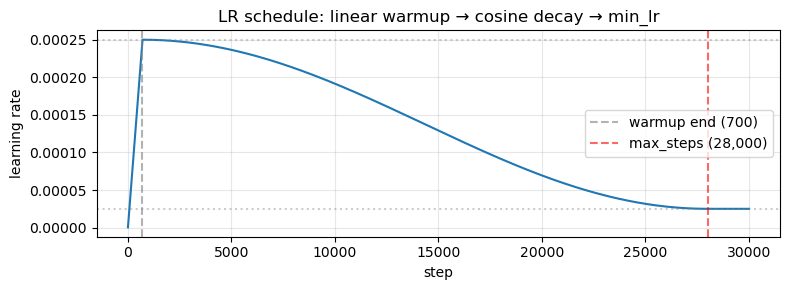

In [9]:
MAX_STEPS    = 28_000
WARMUP_STEPS = 700


def get_lr(
    step: int,
    peak_lr: float = PEAK_LR,
    min_lr: float = MIN_LR,
    warmup_steps: int = WARMUP_STEPS,
    max_steps: int = MAX_STEPS,
) -> float:
    if step < warmup_steps:
        return peak_lr * (step + 1) / warmup_steps
    if step >= max_steps:
        return min_lr
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_lr + (peak_lr - min_lr) * coeff


def set_lr(optimizer, lr: float):
    for g in optimizer.param_groups:
        g["lr"] = lr


# Plot the schedule a bit past max_steps to show the floor
steps = list(range(MAX_STEPS + 2_000))
lrs   = [get_lr(s) for s in steps]

plt.figure(figsize=(8, 3))
plt.plot(steps, lrs)
plt.axvline(WARMUP_STEPS, color="gray", linestyle="--", alpha=0.6, label=f"warmup end ({WARMUP_STEPS})")
plt.axvline(MAX_STEPS,    color="red",  linestyle="--", alpha=0.6, label=f"max_steps ({MAX_STEPS:,})")
plt.axhline(PEAK_LR, color="gray", linestyle=":", alpha=0.4)
plt.axhline(MIN_LR,  color="gray", linestyle=":", alpha=0.4)
plt.xlabel("step")
plt.ylabel("learning rate")
plt.title("LR schedule: linear warmup → cosine decay → min_lr")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10 — Continuation tests

Two complementary eval angles, defined here so the training loop in §12 can use the scored variant during periodic eval:

- **Eyeball suite** (`EYEBALL_PROMPTS`) — fixed prompts grouped by category: factual, narrative, code, instructional, list, arithmetic. Run greedy + sampled at the end (§15). Catches mode collapse, repetition loops, and category-coverage gaps that loss/PPL miss.
- **Scored continuations** (`SCORED_CONTINUATIONS`, `score_continuations`) — prompts paired with a known good continuation. Two numbers per call:
  - **mean NLL** — teacher-forced cross-entropy on the expected tokens. Same units as `val/loss`. Drops as the model learns.
  - **match accuracy** — fraction of prompts whose greedy decode contains the expected string. Coarse but interpretable.

The scored set is small (N≈12), so per-eval noise is real — interpret the trend across many evals, not single points. Untrained baseline is ~ln(50257) ≈ 10.82 NLL and ~0% match.

In [10]:
# ---- Qualitative eyeball suite: prompts grouped by capability ----
EYEBALL_PROMPTS = {
    "factual": [
        "The capital of France is",
        "Photosynthesis is the process by which plants",
        "The speed of light in a vacuum is approximately",
    ],
    "narrative": [
        "Once upon a time, in a small village by the sea,",
        "The detective opened the door and immediately knew that",
    ],
    "code": [
        "def fibonacci(n):\n    ",
        "# Python: read a CSV file with pandas\nimport pandas as pd\n",
    ],
    "instructional": [
        "To bake a loaf of bread, first",
        "The three branches of the United States government are",
    ],
    "list": [
        "The planets of the solar system, in order from the Sun, are: Mercury, Venus,",
        "Some common programming languages include Python, Java, JavaScript,",
    ],
    "arithmetic": [
        "Two plus two equals",
        "Twelve times twelve is",
    ],
}

# ---- Scored continuations: (prompt, expected continuation) ----
# Used for teacher-forced NLL and substring-match accuracy.
# Leading space on the expected string keeps tiktoken's BPE alignment correct.
SCORED_CONTINUATIONS = [
    ("The capital of France is",                                  " Paris"),
    ("The largest planet in our solar system is",                 " Jupiter"),
    ("Water boils at 100 degrees",                                " Celsius"),
    ("The chemical symbol for gold is",                           " Au"),
    ("Shakespeare wrote a famous play called Romeo and",          " Juliet"),
    ("The Pacific is the largest",                                " ocean"),
    ("Mount Everest is the tallest mountain in the",              " world"),
    ("DNA stands for deoxyribonucleic",                           " acid"),
    ("The square root of 144 is",                                 " 12"),
    ("In binary, the number two is written as",                   " 10"),
    ("The fastest land animal is the",                            " cheetah"),
    ("The author of Pride and Prejudice is Jane",                 " Austen"),
]


@torch.no_grad()
def score_continuations(model, items=SCORED_CONTINUATIONS, max_new_tokens: int = 12):
    """
    Two metrics over (prompt, expected) pairs:
      - mean_nll:  per-prompt mean cross-entropy of the expected tokens given
                   the prompt (teacher-forced; same units as val loss).
      - match_acc: fraction of prompts whose greedy decode contains expected.
    """
    was_training = model.training
    model.eval()
    use_amp = device.type == "cuda"

    nlls = []
    matches = 0
    for prompt, expected in items:
        prompt_ids   = tokenizer.encode(prompt, allowed_special={"<|endoftext|>"})
        expected_ids = tokenizer.encode(expected)
        if not expected_ids:
            continue

        # Teacher-forced NLL on the expected tokens
        full = torch.tensor(prompt_ids + expected_ids, dtype=torch.long, device=device).unsqueeze(0)
        with torch.autocast(device_type=device.type, dtype=dtype, enabled=use_amp):
            logits = model(full[:, :-1])                      # [1, L-1, V]
        start = len(prompt_ids) - 1
        target_logits = logits[0, start:start + len(expected_ids), :].float()
        targets = torch.tensor(expected_ids, device=device)
        nll = nn.functional.cross_entropy(target_logits, targets, reduction="mean").item()
        nlls.append(nll)

        # Greedy decode + substring match
        idx = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0)
        gen = generate(model, idx, max_new_tokens=max_new_tokens,
                       context_size=CONTEXT_LENGTH, temperature=0.0, top_k=None)
        decoded = tokenizer.decode(gen[0, len(prompt_ids):].tolist())
        if expected.lstrip().lower() in decoded.lower():
            matches += 1

    if was_training:
        model.train()

    return {
        "mean_nll":  sum(nlls) / max(len(nlls), 1),
        "match_acc": matches / max(len(items), 1),
        "n":         len(items),
    }


# Smoke test: on a fresh / untrained model, expect ~ln(50257) ≈ 10.82 NLL and ~0% match.
print("Smoke test:")
res = score_continuations(model)
print(f"  mean NLL on expected continuations: {res['mean_nll']:.3f}")
print(f"  greedy match accuracy:              {res['match_acc']:.1%}  ({res['n']} prompts)")

Smoke test:
  mean NLL on expected continuations: 11.192
  greedy match accuracy:              0.0%  (12 prompts)


## 11 — Checkpointing

We bundle everything needed to resume training into a single `.pt` file:

- `model_state` — model weights
- `optimizer_state` — AdamW running moments (without these, resuming throws away momentum and learning effectively restarts)
- `step` — current optimizer step (so the LR schedule resumes at the right phase)
- `train_losses` / `val_losses` / `lr_history` — for plotting and analysis
- `config` — frozen `CONFIG` so we know what architecture this checkpoint matches

### Disk-aware design

Each save for GPT-2 Large is **~9 GB** (3 GB model + 6 GB AdamW `m,v` states). With `SAVE_EVERY=2000` over 28 000 steps that's 14 step-keyed saves = ~130 GB. To keep disk usage bounded, `save_checkpoint_rotated` keeps only the last `KEEP_LAST_N` step-keyed checkpoints plus the always-overwritten `checkpoint_latest.pt`.

Defaults: `KEEP_LAST_N=3` → max ~36 GB on disk. Inspect / pin specific checkpoints by copying them out of `../checkpoints/` before the next save rotates them.

In [11]:
LATEST_CKPT  = CHECKPOINT_DIR / "checkpoint_latest.pt"
KEEP_LAST_N  = 3


def checkpoint_path(step: int) -> Path:
    return CHECKPOINT_DIR / f"checkpoint_step{step:06d}.pt"


def save_checkpoint(
    path: Path,
    model,
    optimizer,
    step: int,
    train_losses: list,
    val_losses: list,
    lr_history: list,
    docs_consumed: int = 0,
):
    payload = {
        "step":            step,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_losses":    train_losses,
        "val_losses":      val_losses,
        "lr_history":      lr_history,
        "docs_consumed":   docs_consumed,
        "config":          dict(CONFIG),
    }
    torch.save(payload, path)


def save_checkpoint_rotated(model, optimizer, step, train_losses, val_losses, lr_history,
                            docs_consumed: int = 0, keep_last_n: int = KEEP_LAST_N):
    """Save step-keyed checkpoint + latest pointer; delete oldest beyond keep_last_n."""
    p = checkpoint_path(step)
    save_checkpoint(p, model, optimizer, step, train_losses, val_losses, lr_history, docs_consumed)
    save_checkpoint(LATEST_CKPT, model, optimizer, step, train_losses, val_losses, lr_history, docs_consumed)

    # Rotate: keep only the most recent N step-keyed files
    step_files = sorted(CHECKPOINT_DIR.glob("checkpoint_step*.pt"))
    for old in step_files[:-keep_last_n]:
        old.unlink()
    return p


def load_checkpoint(path: Path, model, optimizer=None):
    payload = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(payload["model_state"])
    if optimizer is not None and "optimizer_state" in payload:
        optimizer.load_state_dict(payload["optimizer_state"])
    return {
        "step":          payload["step"],
        "train_losses":  payload.get("train_losses",  []),
        "val_losses":    payload.get("val_losses",    []),
        "lr_history":    payload.get("lr_history",    []),
        "docs_consumed": payload.get("docs_consumed", 0),   # 0 for legacy checkpoints
    }


# Smoke test: save -> load -> verify weights match
print("Smoke test: save → load → verify...")
test_path = CHECKPOINT_DIR / "_smoke_test.pt"
save_checkpoint(test_path, model, optimizer, step=0,
                train_losses=[], val_losses=[], lr_history=[], docs_consumed=0)

before = {k: v.clone() for k, v in model.state_dict().items()}
state  = load_checkpoint(test_path, model, optimizer)
after  = model.state_dict()

ok = all(torch.equal(before[k], after[k]) for k in before)
print(f"  weights identical after roundtrip: {ok}")
print(f"  resumed step: {state['step']}  |  docs_consumed: {state['docs_consumed']}")
print(f"  ckpt size:    {test_path.stat().st_size / 1024**3:.2f} GB")
test_path.unlink()
print("  cleaned up.")

Smoke test: save → load → verify...
  weights identical after roundtrip: True
  resumed step: 0  |  docs_consumed: 0
  ckpt size:    3.12 GB
  cleaned up.


## 12 — Training loop

Pulling everything together. The loop is structured around two clocks:

- **Micro-step** — one forward+backward on a `BATCH_SIZE` batch. Loss is scaled by `1 / GRAD_ACCUM_STEPS` so accumulated gradients average correctly.
- **Optimizer step** — every `GRAD_ACCUM_STEPS` micro-steps: update LR, clip gradients, step AdamW, zero grads, log, optionally sample/eval/save. **All step counts (`MAX_STEPS`, `WARMUP_STEPS`, `EVAL_EVERY`, etc.) refer to optimizer steps.**

### Cadences (Plan C — long run)

| Knob | Value | What |
|---|---|---|
| `LOG_EVERY` | 50 | Print train loss + PPL + tokens/sec (560 lines over 28K steps). |
| `SAMPLE_EVERY` | 200 | Generate + print an inference sample to eyeball qualitative progress (~140 samples). |
| `EVAL_EVERY` | 500 | Run val loss on `EVAL_BATCHES` **and** scored continuations from §10 (~56 evals). |
| `SAVE_EVERY` | 200 | Checkpoint to disk with rotation (~140 saves; rotation keeps last 3 → max ~36 GB on disk). |
| `GRAD_CLIP` | 1.0 | Max grad L2 norm. |

### W&B metrics

- Per optimizer step: `train/loss`, `train/ppl`, `train/lr`, `train/grad_norm`, `train/tok_per_sec`, `tokens_seen`.
- Per sample (`SAMPLE_EVERY`): `train/sample` (HTML).
- Per eval (`EVAL_EVERY`): `val/loss`, `val/ppl`, `cont/mean_nll`, `cont/match_acc` (scored continuations from §10).

The `train()` function takes `start_step` and existing loss lists, so resuming from a checkpoint is just `train(..., start_step=ckpt["step"], train_losses=ckpt["train_losses"], ...)`.

> **Multi-day run note:** the loop is purely Python — interrupting with `KeyboardInterrupt` is safe. The latest in-memory state is held in module-level `train_losses` / `val_losses` / `lr_history` lists; the most recent disk checkpoint is at `checkpoint_latest.pt`. Resume by reloading that checkpoint and calling `train(...)` again.
>
> **Disk note:** with `SAVE_EVERY=200` the I/O cost is ~9 GB written every ~70 minutes. Rotation (`KEEP_LAST_N=3`) keeps the working set bounded, but if you want to pin a specific step's checkpoint, copy it out of `../checkpoints/` before three more saves rotate it away.

In [12]:
LOG_EVERY     = 50
SAMPLE_EVERY  = 200
EVAL_EVERY    = 500
SAVE_EVERY    = 200
GRAD_CLIP     = 1.0
SAMPLE_PROMPT = "The quick brown fox"


def train(
    model,
    optimizer,
    train_loader,
    val_loader,
    max_steps:        int = MAX_STEPS,
    grad_accum_steps: int = GRAD_ACCUM_STEPS,
    grad_clip:        float = GRAD_CLIP,
    eval_every:       int = EVAL_EVERY,
    eval_batches:     int = EVAL_BATCHES,
    sample_every:     int = SAMPLE_EVERY,
    save_every:       int = SAVE_EVERY,
    log_every:        int = LOG_EVERY,
    sample_prompt:    str = SAMPLE_PROMPT,
    start_step:       int = 0,
    train_losses:     list | None = None,
    val_losses:       list | None = None,
    lr_history:       list | None = None,
    use_wandb:        bool = True,
):
    train_losses = train_losses if train_losses is not None else []
    val_losses   = val_losses   if val_losses   is not None else []
    lr_history   = lr_history   if lr_history   is not None else []
    wandb_active = use_wandb and wandb.run is not None

    model.train()
    optimizer.zero_grad(set_to_none=True)

    step       = start_step
    micro_step = 0
    accum_loss = 0.0
    train_iter = iter(train_loader)
    t0         = time.time()
    tokens_seen = start_step * grad_accum_steps * BATCH_SIZE * CONTEXT_LENGTH

    while step < max_steps:
        # ---- one micro-batch ----
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        loss = calc_loss_batch(x, y, model) / grad_accum_steps
        loss.backward()
        accum_loss += loss.item() * grad_accum_steps   # un-scale for reporting
        micro_step += 1

        # ---- one optimizer step every grad_accum_steps micro-batches ----
        if micro_step % grad_accum_steps != 0:
            continue

        lr = get_lr(step)
        set_lr(optimizer, lr)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        mean_train_loss = accum_loss / grad_accum_steps
        train_losses.append(mean_train_loss)
        lr_history.append(lr)
        accum_loss = 0.0
        step += 1
        tokens_seen += grad_accum_steps * BATCH_SIZE * CONTEXT_LENGTH

        elapsed     = time.time() - t0
        local_step  = step - start_step
        tok_per_sec = local_step * grad_accum_steps * BATCH_SIZE * CONTEXT_LENGTH / max(elapsed, 1e-9)

        if wandb_active:
            wandb.log({
                "train/loss":      mean_train_loss,
                "train/ppl":       perplexity(mean_train_loss),
                "train/lr":        lr,
                "train/grad_norm": grad_norm.item() if torch.is_tensor(grad_norm) else float(grad_norm),
                "train/tok_per_sec": tok_per_sec,
                "tokens_seen":     tokens_seen,
                "docs_consumed":   train_loader.dataset.docs_consumed,
            }, step=step)

        # ---- logging ----
        if step % log_every == 0:
            print(f"step {step:6d}/{max_steps} | lr {lr:.2e} | train_loss {mean_train_loss:.3f} | ppl {perplexity(mean_train_loss):,.1f} | {tok_per_sec/1e3:.1f}K tok/s")

        # ---- periodic inference sample ----
        if step % sample_every == 0:
            print(f"  sample @ step {step}:")
            sample_text = generate_and_print_sample(model, sample_prompt, max_new_tokens=40)
            if wandb_active:
                wandb.log({
                    "train/sample": wandb.Html(f"<pre>{sample_text}</pre>"),
                }, step=step)
            model.train()
            print()

        # ---- periodic eval (val loss + scored continuations) ----
        if step % eval_every == 0 or step == max_steps:
            val_loss = calc_loss_loader(val_loader, model, num_batches=eval_batches)
            val_losses.append((step, val_loss))
            cont = score_continuations(model)
            print(f"  eval @ step {step}: val_loss {val_loss:.3f} | PPL {perplexity(val_loss):,.1f}")
            print(f"  cont @ step {step}: mean_nll {cont['mean_nll']:.3f} | match_acc {cont['match_acc']:.1%}  ({cont['n']} prompts)")
            if wandb_active:
                wandb.log({
                    "val/loss":       val_loss,
                    "val/ppl":        perplexity(val_loss),
                    "cont/mean_nll":  cont["mean_nll"],
                    "cont/match_acc": cont["match_acc"],
                }, step=step)
            model.train()
            print()

        # ---- checkpoint with rotation ----
        if step % save_every == 0 or step == max_steps:
            docs_consumed = train_loader.dataset.docs_consumed
            p = save_checkpoint_rotated(
                model, optimizer, step, train_losses, val_losses, lr_history,
                docs_consumed=docs_consumed,
            )
            print(f"  saved {p.name}  ({docs_consumed:,} train docs consumed)\n")

    return train_losses, val_losses, lr_history


print("train() defined.")

train() defined.


## 13 — Run training

Set `RESUME = True` to continue from `checkpoint_latest.pt` (model + AdamW state + step + loss history all restored). Set `RESUME = False` for a fresh run from step 0.

The cell captures `train_losses`, `val_losses`, `lr_history` into module-level lists so the next section can plot them.

### W&B logging

Training streams metrics to [Weights & Biases](https://wandb.ai/) via `wandb.init(...)`. Run `wandb login` once in your shell, or set `WANDB_API_KEY` before launching the notebook. Set `WANDB_MODE=offline` for an air-gapped run, or pass `use_wandb=False` to `train(...)` to disable entirely.

Logged per optimizer step: `train/loss`, `train/ppl`, `train/lr`, `train/grad_norm`, `train/tok_per_sec`, `tokens_seen`. Logged per eval: `val/loss`, `val/ppl`, `cont/mean_nll`, `cont/match_acc`, plus an HTML sample of the generation.

### Before kicking off (multi-day run):

- Confirm `~/.cache/huggingface` has ~20–30 GB free for streamed shards
- Confirm `../checkpoints/` has ~40 GB free
- Watch the first ~5 optimizer steps for OOM. If `BATCH_SIZE=2` OOMs, restart with `BATCH_SIZE=1` and `GRAD_ACCUM_STEPS=512` in cell 6 (effective batch unchanged)
- Throughput at step 50 (after warmup of CUDA kernels) is the truth — extrapolate from there to confirm the wall-clock estimate

In [ ]:
RESUME       = False                  # flip to True to continue from checkpoints/checkpoint_latest.pt
USE_WANDB    = True                   # flip to False to disable W&B entirely
WANDB_PROJECT = "gpt2-large-fineweb-edu"
WANDB_RUN_NAME = None                 # None → wandb auto-generates; set a string to pin a name

if RESUME and LATEST_CKPT.exists():
    print(f"Resuming from {LATEST_CKPT.name}...")
    state         = load_checkpoint(LATEST_CKPT, model, optimizer)
    start_step    = state["step"]
    train_losses  = state["train_losses"]
    val_losses    = state["val_losses"]
    lr_history    = state["lr_history"]
    docs_consumed = state["docs_consumed"]
    print(f"  resumed at step {start_step:,}")
    print(f"  history points: train={len(train_losses)}, val={len(val_losses)}")
    if docs_consumed > 0:
        print(f"  rebuilding train loader to skip {docs_consumed:,} docs already seen...")
        train_loader, val_loader = build_dataloaders(skip_train_docs=docs_consumed)
    else:
        print("  legacy checkpoint (no docs_consumed) — train stream restarts from doc 0.")
else:
    if RESUME:
        print(f"RESUME=True but {LATEST_CKPT.name} not found — starting fresh.")
    print("Cold start from step 0.")
    start_step   = 0
    train_losses = []
    val_losses   = []
    lr_history   = []

# ---- W&B init ----
if USE_WANDB:
    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        resume="allow",
        config={
            **CONFIG,
            "batch_size":         BATCH_SIZE,
            "grad_accum_steps":   GRAD_ACCUM_STEPS,
            "effective_batch_tokens": BATCH_SIZE * GRAD_ACCUM_STEPS * CONTEXT_LENGTH,
            "context_length":     CONTEXT_LENGTH,
            "peak_lr":            PEAK_LR,
            "min_lr":             MIN_LR,
            "betas":              BETAS,
            "eps":                EPS,
            "weight_decay":       WEIGHT_DECAY,
            "max_steps":          MAX_STEPS,
            "warmup_steps":       WARMUP_STEPS,
            "grad_clip":          GRAD_CLIP,
            "dataset":            DATASET_NAME,
            "dataset_subset":     DATASET_SUBSET,
            "val_docs":           VAL_DOCS,
            "shuffle_buffer":     SHUFFLE_BUFFER,
            "seed":               SEED,
            "dtype":              str(dtype),
            "gradient_checkpointing": getattr(model, "gradient_checkpointing", False),
        },
    )
    wandb.watch(model, log=None, log_freq=LOG_EVERY)
    print(f"W&B run: {wandb.run.name}  →  {wandb.run.url}")

# ---- train ----
try:
    train_losses, val_losses, lr_history = train(
        model, optimizer, train_loader, val_loader,
        start_step=start_step,
        train_losses=train_losses,
        val_losses=val_losses,
        lr_history=lr_history,
        use_wandb=USE_WANDB,
    )
finally:
    if USE_WANDB and wandb.run is not None:
        wandb.finish()

print(f"\nDone. Total optimizer steps: {len(train_losses):,}")
print(f"Final train loss: {train_losses[-1]:.3f}   PPL: {perplexity(train_losses[-1]):,.1f}")
if val_losses:
    last_step, last_val = val_losses[-1]
    print(f"Final val loss @ step {last_step:,}: {last_val:.3f}   PPL: {perplexity(last_val):,.1f}")

Cold start from step 0.


wandb: Currently logged in as: bmartins to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run: silver-morning-3  →  https://wandb.ai/bmartins/gpt2-large-fineweb-edu/runs/enrgea0p
step     50/28000 | lr 1.79e-05 | train_loss 8.745 | ppl 6,281.0 | 4.5K tok/s
step    100/28000 | lr 3.57e-05 | train_loss 7.465 | ppl 1,746.5 | 4.5K tok/s
step    150/28000 | lr 5.36e-05 | train_loss 6.927 | ppl 1,019.0 | 4.5K tok/s
step    200/28000 | lr 7.14e-05 | train_loss 6.622 | ppl 751.4 | 4.5K tok/s
  sample @ step 200:
The quick brown fox to the United States.
-5-10:
-4. (C.
- The U2.
|- A/or-
-
- "-4- How

  saved checkpoint_step000200.pt  (101,159 train docs consumed)

step    250/28000 | lr 8.93e-05 | train_loss 6.355 | ppl 575.5 | 4.5K tok/s
step    300/28000 | lr 1.07e-04 | train_loss 6.258 | ppl 522.1 | 4.5K tok/s
step    350/28000 | lr 1.25e-04 | train_loss 6.143 | ppl 465.5 | 4.5K tok/s
step    400/28000 | lr 1.43e-04 | train_loss 5.979 | ppl 395.0 | 4.5K tok/s
  sample @ step 400:
The quick brown fox, and the body. In a study. But the two of the number of the year, the follow

'HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu/resolve/87f09149ef4734204d70ed1d046ddc9ca3f2b8f9/sample/100BT/000_00001.parquet
Retrying in 1s [Retry 1/5].


step   2100/28000 | lr 2.49e-04 | train_loss 3.777 | ppl 43.7 | 4.5K tok/s
step   2150/28000 | lr 2.48e-04 | train_loss 3.693 | ppl 40.2 | 4.5K tok/s
step   2200/28000 | lr 2.48e-04 | train_loss 3.736 | ppl 41.9 | 4.5K tok/s
  sample @ step 2200:
The quick brown foxes in the wild, called “the Black Fox”, and “the Black Fox”. The Black Fox’s black foxes, which are the largest of the Black

  saved checkpoint_step002200.pt  (1,117,476 train docs consumed)

step   2250/28000 | lr 2.48e-04 | train_loss 3.616 | ppl 37.2 | 4.5K tok/s
step   2300/28000 | lr 2.48e-04 | train_loss 3.669 | ppl 39.2 | 4.5K tok/s
step   2350/28000 | lr 2.48e-04 | train_loss 3.524 | ppl 33.9 | 4.5K tok/s
step   2400/28000 | lr 2.48e-04 | train_loss 3.639 | ppl 38.1 | 4.5K tok/s
  sample @ step 2400:
The quick brown fox.
The other day I will be watching, the fox will be trying to eat up.
I will be in the early morning sun and the fox will become very near the base of the snow

  saved checkpoint_step002400.pt  (1,21

ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x727326c64250>> (for post_run_cell), with arguments args (<ExecutionResult object at 727326c45190, execution_count=13 error_before_exec=None error_in_exec=Connection lost info=<ExecutionInfo object at 727326c46a90, raw_cell="RESUME       = False                  # flip to Tr.." transformed_cell="RESUME       = False                  # flip to Tr.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/bmartins/dev/llm_training/explore/train.ipynb#X35sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

: 

## 14 — Post-training: loss curves + samples

Two diagnostics:

1. **Loss curves** — train loss every optimizer step plus the sparser val loss points, on a log-y axis. A healthy run shows a steady drop with val tracking train (a small persistent gap is fine; a widening gap = overfitting). The LR history is plotted alongside as a sanity check that the schedule fired correctly.
2. **Generation samples at varying temperature** — argmax (`T=0`), moderate (`T=0.7`), high (`T=1.0`). Same prompt, different sampling. Argmax is the "what did the model actually learn" view; higher temperatures show the diversity of the learned distribution.

In [ ]:
# ---- 1. Loss curves + LR history ----
fig, (ax_loss, ax_lr) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

train_steps = list(range(1, len(train_losses) + 1))
ax_loss.plot(train_steps, train_losses, label="train", alpha=0.6, linewidth=0.8)
if val_losses:
    val_steps_x, val_y = zip(*val_losses)
    ax_loss.plot(val_steps_x, val_y, marker="o", color="tab:red", label="val", linewidth=1.4)
ax_loss.axhline(uniform_loss, color="gray", linestyle=":", alpha=0.5, label=f"uniform ({uniform_loss:.2f})")
ax_loss.set_yscale("log")
ax_loss.set_ylabel("cross-entropy loss")
ax_loss.set_title("Training curves — GPT-2 Large on FineWeb-Edu")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

ax_lr.plot(train_steps, lr_history, color="tab:green")
ax_lr.set_xlabel("optimizer step")
ax_lr.set_ylabel("lr")
ax_lr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ---- 2. Final generation samples at varying temperature ----
prompts = [
    "The quick brown fox",
    "In a shocking finding, scientists discovered",
    "The history of artificial intelligence",
]

for prompt in prompts:
    print(f"\n=== Prompt: {prompt!r} ===")
    for T, top_k in [(0.0, None), (0.7, 50), (1.0, 50)]:
        label = "argmax" if T == 0.0 else f"T={T}, top_k={top_k}"
        print(f"\n--- {label} ---")
        generate_and_print_sample(
            model, prompt,
            max_new_tokens=80,
            temperature=T,
            top_k=top_k,
        )

## 15 — Continuation test suite (final)

The full qualitative + scored read on the trained model, using the prompts and helpers defined in §10.

- **Eyeball** — every prompt in `EYEBALL_PROMPTS`, each generated greedy and at `T=0.7, top_k=50`, grouped by category. Look for: on-topic continuations, no immediate repetition loops, plausible factual content in the factual / list sections, syntactically sane code in the code section.
- **Scored** — same `SCORED_CONTINUATIONS` set the training loop tracked. Final aggregate `mean_nll` / `match_acc` plus per-prompt detail so you can see *which* prompts the model nails vs. flubs. Compare these numbers against the curve in W&B's `cont/*` panels to confirm the final checkpoint matches the trend.

In [ ]:
# ---- 1. Eyeball suite: greedy + sampled, grouped by category ----
print("=" * 72)
print("EYEBALL SUITE")
print("=" * 72)

for category, prompts in EYEBALL_PROMPTS.items():
    print(f"\n### {category.upper()} ###")
    for prompt in prompts:
        print(f"\n--- prompt: {prompt!r} ---")
        for label, T, k in [("greedy", 0.0, None), ("T=0.7, top_k=50", 0.7, 50)]:
            print(f"[{label}]")
            generate_and_print_sample(
                model, prompt,
                max_new_tokens=50,
                temperature=T,
                top_k=k,
            )

# ---- 2. Scored continuations: aggregate + per-prompt detail ----
print("\n" + "=" * 72)
print("SCORED CONTINUATIONS")
print("=" * 72)

agg = score_continuations(model)
print(f"\nmean NLL (teacher-forced):  {agg['mean_nll']:.3f}")
print(f"greedy match accuracy:      {agg['match_acc']:.1%}  ({agg['n']} prompts)")

# Per-prompt detail: greedy decode + hit/miss against the expected continuation
print("\nPer-prompt detail (greedy decode, first ~12 tokens):")
print("-" * 72)
for prompt, expected in SCORED_CONTINUATIONS:
    prompt_ids = tokenizer.encode(prompt, allowed_special={"<|endoftext|>"})
    idx = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0)
    gen = generate(model, idx, max_new_tokens=12,
                   context_size=CONTEXT_LENGTH, temperature=0.0, top_k=None)
    decoded = tokenizer.decode(gen[0, len(prompt_ids):].tolist())
    hit = "PASS" if expected.lstrip().lower() in decoded.lower() else "FAIL"
    print(f"  [{hit}] {prompt!r}")
    print(f"         expected: {expected!r}")
    print(f"         greedy:   {decoded!r}")